# [LAB12] 딥러닝 > 신경망의 이해 > 2. 퍼셉트론

## #01. 퍼셉트론 개요

- 인공신경망(딥러닝)의 기원이 되는 알고리즘.
- 하나 이상의 신호를 입력받아 어떠한 계산을 수행한 후 하나의 Output를 출력한다.
- 퍼셉트론은 `1` 과 `0` 의 신호만 가질 수 있다.
- 신호가 흐르면 `1` , 흐르지 않으면 `0` 이다.

### [1] input이 2개인 퍼셉트론

- $x_1$과 $x_2$는 입력 신호, $y$는 출력 신호, $w_1$과 $w_2$는 가중치를 의미한다. (w : weight)
- $x$와 가중치 $w$를 곱한 값을 모두 더하여 하나의 값($y$)로 만들어 낸다.
- 입력 신호가 뉴런에 보내질 때는 각각 고유한 가중치가 곱해지고 그 값들을 모두 더해서 나온 값($y$)이 어떠한 임계값($\theta$)을 넘을 때만 1로 출력한다.
- 신경망에서 만들어진 값($y$)을 적절한 출력값으로 변환해 주는 함수를 **활성화 함수**라고 한다.
- 입력 신호와 출력 신호를 담고있는 원은 **노드** 혹은 **뉴런**이라 부른다.

위 그림을 수식으로 표현하면 아래와 같다.

$$y = \left \{ \begin{array}{cc} {0 \quad (w_1x_1 + w_2x_2 \leq \theta)}\\ {1 \quad (w_1x_1 + w_2x_2 > \theta)} \end{array} \right.$$

### (1) 논리회로

- 논리 연산을 통해 전기 장치를 제어하는 통로.
- 컴퓨터 및 기타 전기 장치를 작동하게 만드는 기본 부품이다.
- 불 대수를 이용하여 설계
- 여러 입력을 해도 1개의 출력만 나온다.

### (2) 게이트

- 논리 회로의 기초 구성요소.
- 각 게이트는 논리 연산 하나를 구현한다.

### (3) 게이트의 종류

| 게이트 | A | B | 출력 |
|--------|---|---|------|
| AND    | 1 | 1 | 1    |
| AND    | 1 | 0 | 0    |
| AND    | 0 | 1 | 0    |
| AND    | 0 | 0 | 0    |

| 게이트 | A | B | 출력 |
|--------|---|---|------|
| OR     | 1 | 1 | 1    |
| OR     | 1 | 0 | 1    |
| OR     | 0 | 1 | 1    |
| OR     | 0 | 0 | 0    |

| 게이트 | A | 출력 |
|--------|---|------|
| NOT    | 1 | 0    |
| NOT    | 0 | 1    |

| 게이트 | A | B | 출력 |
|--------|---|---|------|
| XOR    | 1 | 1 | 0    |
| XOR    | 1 | 0 | 1    |
| XOR    | 0 | 1 | 1    |
| XOR    | 0 | 0 | 0    |

퍼셉트론과 논리회로의 원리가 동일하기 때문에 퍼셉트론을 사용하여 논리회로를 구현할 수 있다.

## #02. AND(OR) Gate

### [1]. 준비작업

#### 패키지 참조

패키지 설치가 필요하다. (다소 오래 걸림)

In [1]:
# !pip install --upgrade tensorflow

In [2]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split

# 순서층을 구성하는 모델 객체 생성 기능
from tensorflow.keras.models import Sequential

# 모델 객체에 학습을 위한 층을 쌓는다.
from tensorflow.keras.layers import Dense, Input

# 옵티마이저
from tensorflow.keras.optimizers import SGD, RMSprop

# 활성화 함수
from tensorflow.keras.losses import mse

# 성능평가함수
from tensorflow.keras.metrics import RootMeanSquaredError

# 로딩바
from tqdm.keras import TqdmCallback

#### 데이터셋 준비

OR 논리 게이트의 입력과 출력 데이터

In [3]:
# origin = load_data("logical_and")
origin = load_data("logical_or")
origin

OR 논리 게이트의 입력과 출력 데이터


,x1,x2,target
0,0,0,0
1,1,0,1
2,0,1,1
3,1,1,1


### [2] 탐색적 데이터 분석

- 결측치와 이상치 등을 확인하고 변환할 데이터가 있다면 처리한다.
- 데이터의 구조와 분포를 확인하기 위한 절차를 진행한다.
- 이 단계에서 각종 시각화 결과물을 생성하고 머신러닝에게 수행시킬 학습의 방향을 결정하게 된다.

#### 데이터 차원 확인

### [3] 데이터 전처리

- 범주형 데이터가 문자열로 되어있다면 숫자로 변환해 준다.
- 데이터셋 분할하기
- 분할된 변수중 연속형 자료(등간척도, 비율척도)에 대해서 필요하다면 정규화나 표준화를 수행한다.

> 간단한 데이터셋이므로 이 예제에서는 생략한다.

In [4]:
# 전체 데이터를 학습용과 테스트용으로 모두 사용
x_train = origin.drop("target", axis=1)
y_train = origin["target"]
x_test = x_train.copy()
y_test = y_train.copy()

In [5]:
rows, cols = x_train.shape
print(rows, cols)

4 2


### [4] 신경망 모델 적합

> **적합**: 주어진 데이터에 대해 모델의 파라미터를 학습시켜 최적의 함수 형태를 찾는 과정

#### 신경망 모델 구축

- `tensorflow.keras.models` 패키지의 `Sequential` 클래스에 대한 `model` 객체를 생성한다.
  - 이 객체의 `add()` 메서드를 통해 신경망층(=Dense층)을 쌓는다.
  - 첫 번째 층을 쌓을 때 **활성화 함수**를 지정해야 한다.
  - **잘 알려진 분석 모델 유형에 대해서는 이미 유형별로 정해져 있음** → 단순 암기
- 학습 성능을 향상시키고 과적합을 방지하기 위해 드롭아웃(Dropout)을 적용할 수 있다. (추후 다룸)
- 층을 다 쌓은 후에는 `model` 객체의 `summary()` 함수를 사용하여 요약 정보를 확인할 수 있다.
- `model` 객체의 `compile()` 함수를 사용하여 구성한 모델을 적용한다.
  - `model` 객체의 `compile()` 함수를 사용할 때 적절한 **옵티마이저**와 **손실함수**를 지정해야 한다.
  - **잘 알려진 분석 모델 유형에 대해서는 이미 유형별로 정해져 있음** → 단순 암기
- 학습 성능을 향상시키기 위한 콜백 함수들을 지정할 수 있다.

| 구분 | 모델 | 활성화 함수 | 옵티마이저 | 손실함수 | 평가지표 | 대표예제 |
|------|------|------------|-----------|---------|---------|--------|
| 논리연산 | 단층퍼셉트론 | linear | SGD | mse | accuracy | OR, AND Gate |

In [6]:
# Sequential API를 사용하여 순차적으로 층을 쌓는 모델 객체 생성
model = Sequential()

# 입력층 정의: 각 샘플은 (cols,) 형태의 1차원 벡터임
# 예) cols=5이면 입력 데이터는 (None, 5) 구조가 됨 (None은 배치 크기)
model.add(Input(shape=(cols,)))

# Dense(완전연결층) 추가
# 출력 뉴런 1개 → 이진 분류 문제이므로 출력층 뉴런 수는 1개
model.add(Dense(1, activation="linear"))

# 모델 학습 설정 (컴파일 단계)
model.compile(
    optimizer="SGD",
    loss="mse",
    metrics=["accuracy", "mae", RootMeanSquaredError(name="rmse")],
)

# 모델 구조(층 구성, 파라미터 개수 등) 요약 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

#### 학습하기

- `model` 객체의 `fit()` 함수를 사용하여 학습을 진행한다.
- 데이터가 크고, 모델이 복잡한 경우 매우 오래 걸린다.
- 학습 결과로 반환받은 객체의 `history` 정보를 확인하면 학습 결과를 검토할 수 있는 항목을 확인할 수 있다.
- 에폭(`epochs`)는 수행할 총 훈련주기이다.
  - 예를 들어 5만건의 데이터를 학습한다고 했을 때 이 데이터셋의 모든 케이스를 1회 확인하면 1에폭이다.
  - 15에폭은 5만건의 데이터를 15회 검토했다는 것을 의미한다.

In [7]:
%%time
result = model.fit(
    x_train,                              # 학습 데이터 입력
    y_train,                              # 학습 데이터의 타겟값 (정답)
    epochs=500,                           # 전체 학습 데이터셋을 500회 반복하여 학습
    validation_split=0.2,                 # 학습 데이터의 20%를 검증용으로 사용 (학습 중 모델 성능 평가에 활용)
    verbose=0,                            # 학습 과정 출력 생략
    callbacks=[TqdmCallback(verbose=1)]   # 학습 진행 상황을 tqdm 형태로 보여주는 콜백 추가
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

CPU times: user 11.9 s, sys: 1.55 s, total: 13.4 s
Wall time: 12.2 s


### [5] 성능평가

- 에폭별 정확도(acc)와 손실률(loss)를 시각화 하여 과적합을 판단한다.
- `hist.history` 객체에 포함된 학습 과정에 대한 데이터를 시각화 하여 학습 과정을 확인할 수 있다.
- `model` 객체의 `evaluate()` 함수를 사용하여 성능을 확인할 수 있다.
- `model` 객체의 `predict()` 함수에 검증용 데이터 셋을 학습된 모델에 적용하여 종속변수에 대한 예측치를 산정한다.
- 실제 종속변수값과 비교하여 정확도를 확인한다.

#### (1) 가중치, 편향 확인

In [8]:
weight, bias = model.get_weights()
print("가중치: %s" % weight)
print("편향: %s" % bias)

가중치: [[0.8272992]
 [0.85671  ]]
편향: [0.11565943]


#### (2) 성능평가 지표

In [9]:
# Train 성능 평가
# -> metrics=["accuracy", "mae", RootMeanSquaredError(name="rmse")]에 의해
# evaluate()가 반환하는 리스트의 순서는 [loss, accuracy, mae, rmse]임
train_eval = model.evaluate(x_train, y_train, verbose=0, return_dict=True)
test_eval = model.evaluate(x_test, y_test, verbose=0, return_dict=True)

# DataFrame 생성
final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, "Dataset", ["Train", "Test"])

# RMSE Gap 추가
final_results["rmse_gap"] = None
final_results.loc[1, "rmse_gap"] = (
    final_results.loc[1, "rmse"] - final_results.loc[0, "rmse"]
)

final_results

,Dataset,accuracy,loss,mae,rmse,rmse_gap
0,Train,1.000,0.164,0.250,0.405,None
1,Test,1.000,0.164,0.250,0.405,0.000


#### (3) 학습 과정 확인

In [10]:
history_df = DataFrame(data=result.history)
history_df["epoch"] = history_df.index + 1
history_df.head()

,accuracy,loss,mae,rmse,val_accuracy,val_loss,val_mae,val_rmse,epoch
0,0.667,0.276,0.327,0.525,1.000,0.001,0.034,0.034,1
1,0.667,0.268,0.322,0.518,1.000,0.002,0.046,0.046,2
2,0.667,0.260,0.318,0.510,1.000,0.003,0.059,0.059,3
3,0.667,0.253,0.314,0.503,1.000,0.005,0.071,0.071,4
4,0.667,0.246,0.310,0.496,1.000,0.007,0.083,0.083,5


#### (4) RMSE 학습곡선

| 패턴 | 의미 |
|------|------|
| Gap ≈ 0 | 정상 학습 |
| Gap 점점 증가 | 과적합 진행 |
| Gap 음수 | Validation이 더 좋음 (샘플 변동 가능성) |

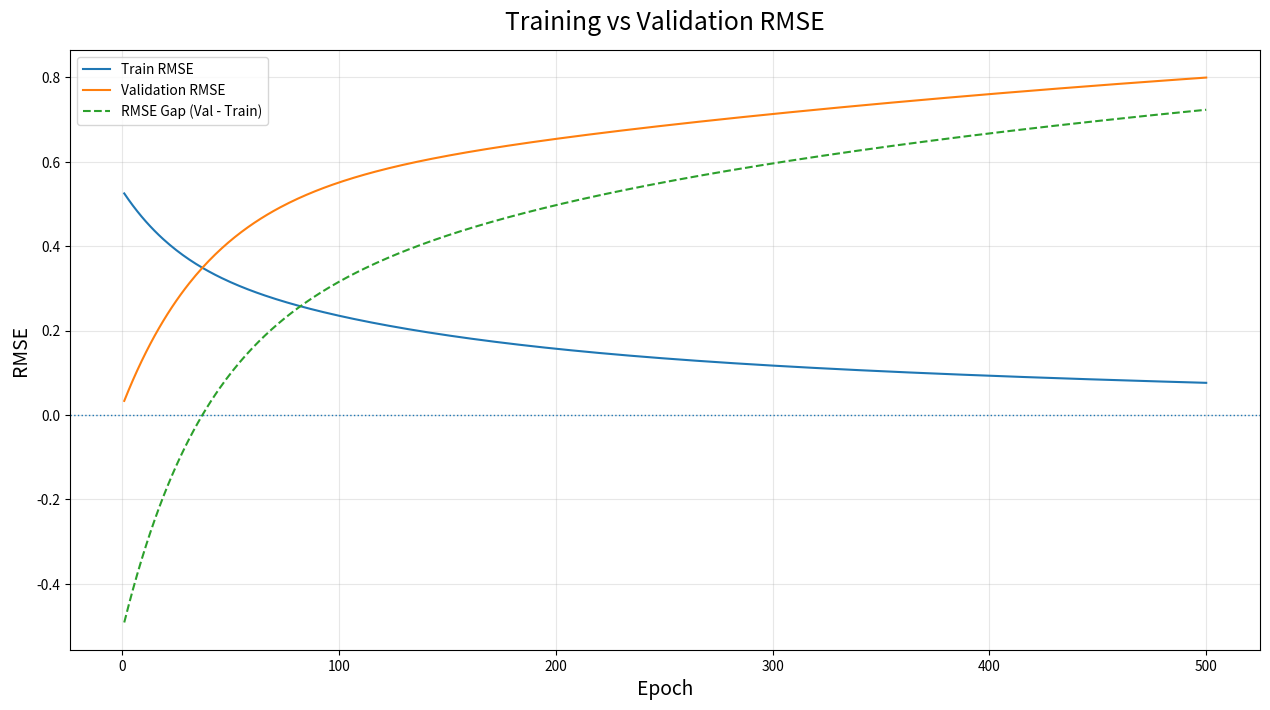

In [11]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

# Train RMSE
sb.lineplot(data=history_df, x="epoch", y="rmse", ax=ax, label="Train RMSE")

# Validation RMSE
sb.lineplot(data=history_df, x="epoch", y="val_rmse", ax=ax, label="Validation RMSE")

# RMSE Gap (보조선)
history_df["rmse_gap"] = history_df["val_rmse"] - history_df["rmse"]
sb.lineplot(
    data=history_df,
    x="epoch",
    y="rmse_gap",
    ax=ax,
    label="RMSE Gap (Val - Train)",
    linestyle="--",
)

# 기준선 (Gap = 0)
ax.axhline(0, linestyle=":", linewidth=1)

ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.set_title("Training vs Validation RMSE")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

#### (5) MAE 시각화

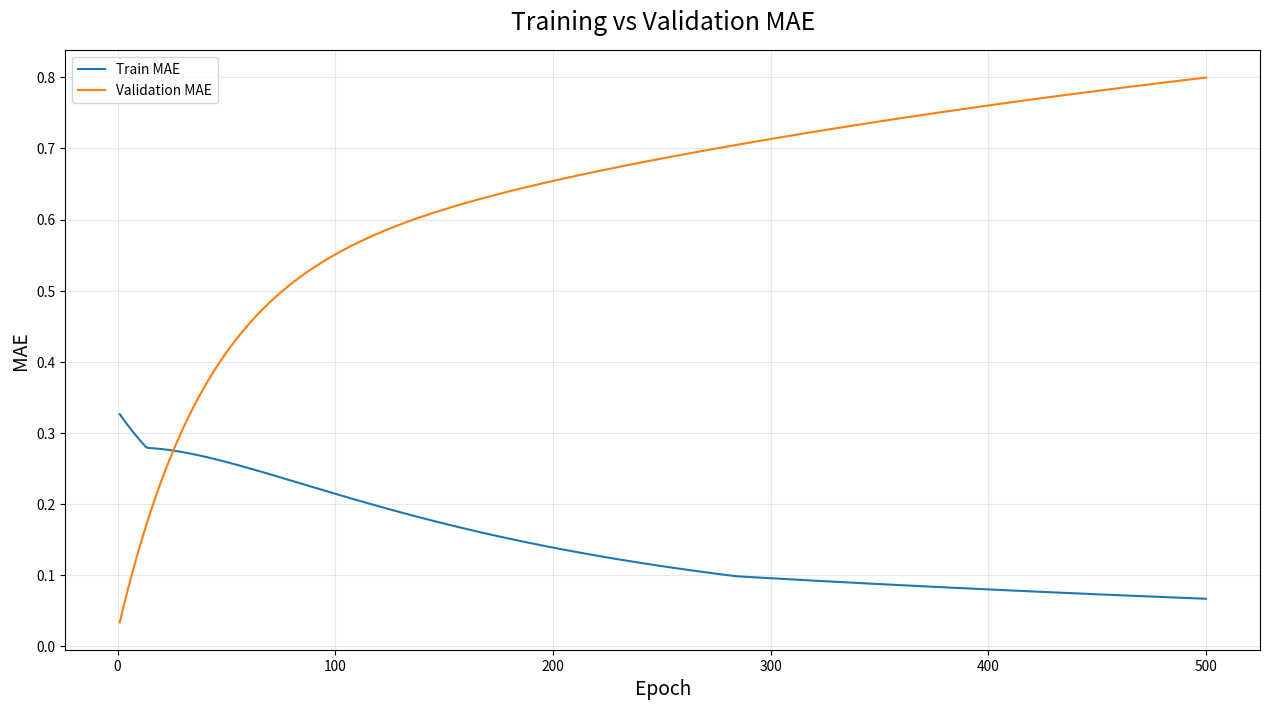

In [12]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

sb.lineplot(data=history_df, x="epoch", y="mae", ax=ax, label="Train MAE")

sb.lineplot(data=history_df, x="epoch", y="val_mae", ax=ax, label="Validation MAE")

ax.set_xlabel("Epoch")
ax.set_ylabel("MAE")
ax.set_title("Training vs Validation MAE")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

#### (6) Loss(MSE) 학습곡선

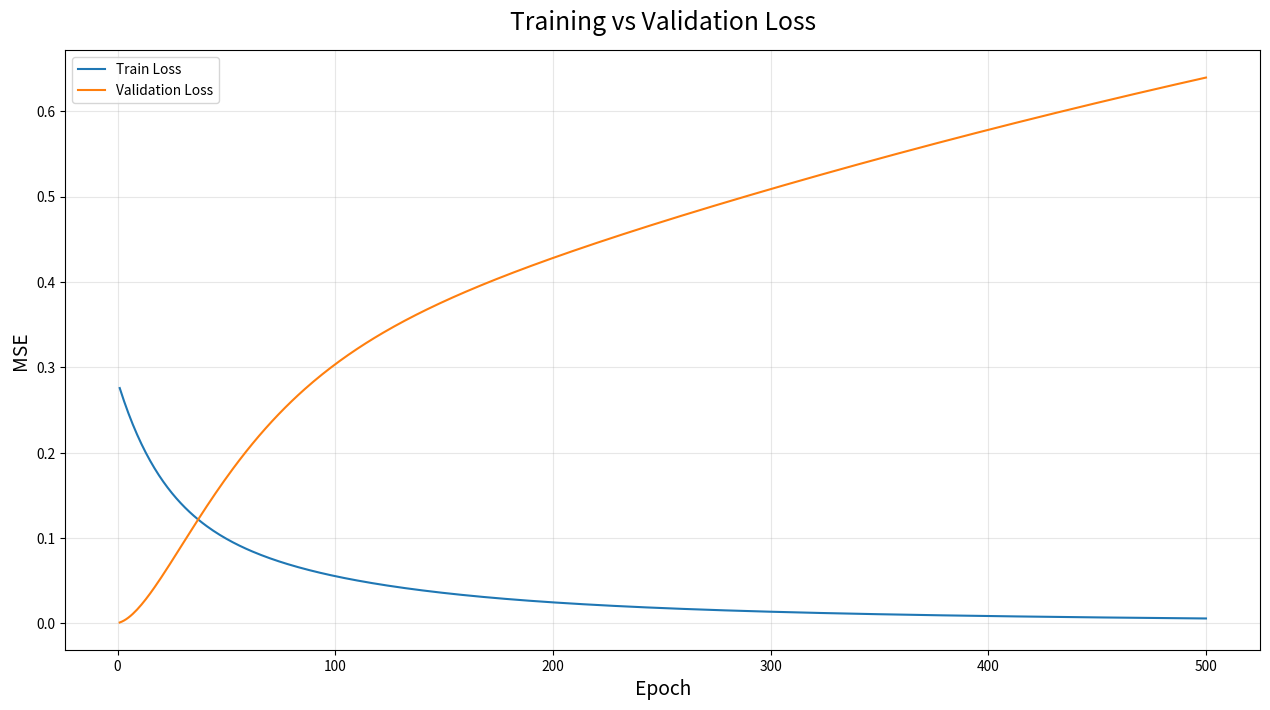

In [13]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

sb.lineplot(data=history_df, x="epoch", y="loss", ax=ax, label="Train Loss")

sb.lineplot(data=history_df, x="epoch", y="val_loss", ax=ax, label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Training vs Validation Loss")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

#### 그래프 비교

| 목적 | 가장 적합 |
|------|----------|
| 학습 안정성 확인 | Loss |
| 오차 크기 해석 | RMSE |
| 이상치 영향 줄인 성능 | MAE |
| 과적합 판단 | RMSE 또는 MAE (Val 비교) |

- Loss(MSE)는 RMSE와 거의 동일 패턴
- MSE는 RMSE의 제곱 관계
- RMSE를 이미 본다면 Loss(MSE) 곡선은 사실상 중복 정보

### [6] 학습 결과 적용

#### (1) 단일 데이터에 대한 예측치 산정

In [14]:
for i in range(0, 2):
    for j in range(0, 2):
        r = model.predict(np.array([[i, j]]), verbose=0)
        print("입력: %d, %d => 출력: %0.2f" % (i, j, r[0][0]))
        print("%s, %s => %s" % (bool(i), bool(j), bool(round(r[0, 0]))))

입력: 0, 0 => 출력: 0.12
False, False => False
입력: 0, 1 => 출력: 0.97
False, True => True
입력: 1, 0 => 출력: 0.94
True, False => True
입력: 1, 1 => 출력: 1.80
True, True => True


#### (2) 검증 데이터 전체를 활용하여 예측값 만들기

In [15]:
r = model.predict(x_test, verbose=0)
r

array([[0.11565943],
       [0.9429586 ],
       [0.97236943],
       [1.7996687 ]], dtype=float32)

In [16]:
origin["pred"] = r.reshape(-1).round()
origin

,x1,x2,target,pred
0,0,0,0,0.000
1,1,0,1,1.000
2,0,1,1,1.000
3,1,1,1,2.000


## 연구과제

다음은 XOR Gate에 적용해야 하는 신경망 구조이다.

`logical_xor` 데이터셋에 대한 신경망을 구축하고 결과를 확인하라.

| 구분 | 모델 | 활성화 함수 | 옵티마이저 | 손실함수 | 평가지표 | 대표예제 |
|------|------|------------|-----------|---------|---------|--------|
| 논리연산 | 다층퍼셉트론 | relu, sigmoid | RMSprop | mse | accuracy | XOR Gate |

In [17]:
# 연구과제: XOR Gate 신경망 구현
# logical_xor 데이터셋 로드 후 다층퍼셉트론으로 학습